# **WHEEL DIAMETER**

In [ ]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/wheelmtbf.csv')
df

,Date,TrainID,Car,Bogie,Axle,WheelDiameter,WheelFlange,Failure,Quarter,FailuresPerQuarter,DaysInQuarter,MTBF
0,2018-06-22,T01,M1,BOG#1,X1-LHS,843.22,29.02,0,2018Q2,0,91,0.000000
1,2018-06-22,T01,M1,BOG#1,X1-RHS,843.93,29.26,0,2018Q2,0,91,0.000000
2,2018-06-22,T01,M1,BOG#1,X2-LHS,844.14,29.80,0,2018Q2,0,91,0.000000
3,2018-06-22,T01,M1,BOG#1,X2-RHS,844.76,29.53,0,2018Q2,0,91,0.000000
4,2018-06-22,T01,M1,BOG#2,X3-LHS,844.86,29.80,0,2018Q2,0,91,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4918,2025-03-13,T58,M2,BOG#1,X2-RHS,818.00,30.07,0,2025Q1,11,90,147.272727
4919,2025-03-13,T58,M2,BOG#2,X3-LHS,816.30,30.52,0,2025Q1,11,90,147.272727
4920,2025-03-13,T58,M2,BOG#2,X3-RHS,812.10,30.00,0,2025Q1,11,90,147.272727
4921,2025-03-13,T58,M2,BOG#2,X4-LHS,812.10,30.01,0,2025Q1,11,90,147.272727


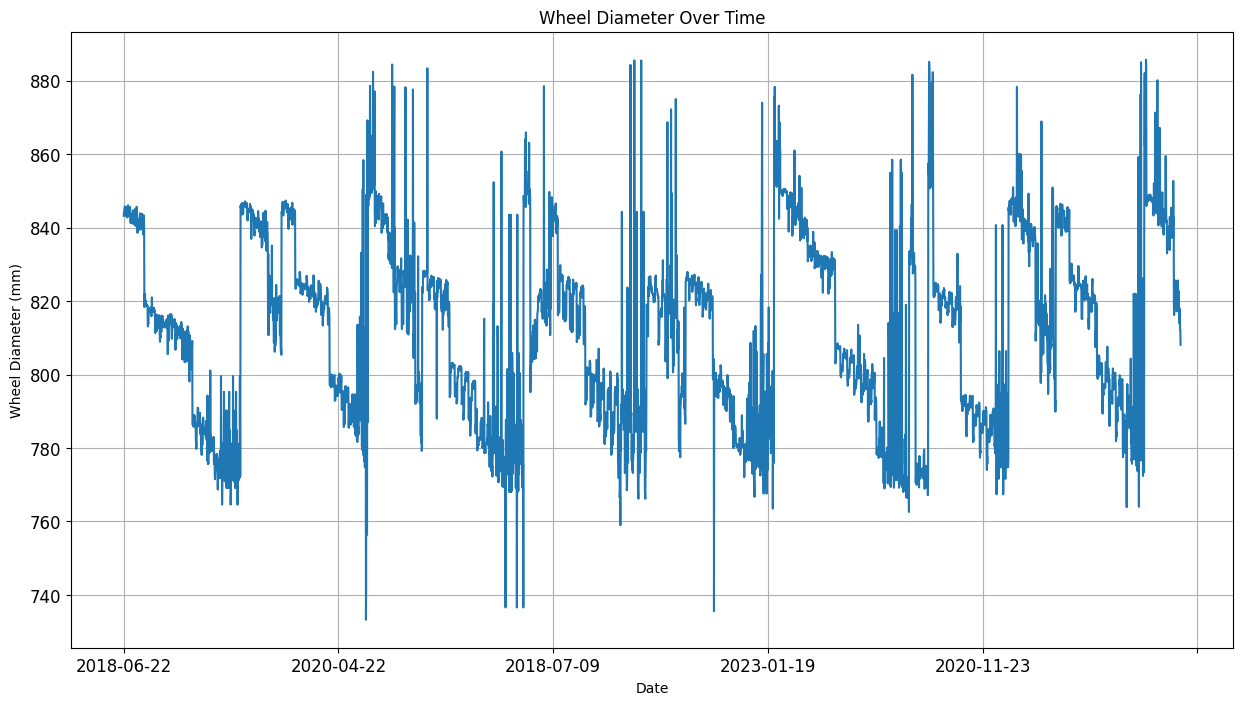

In [ ]:
#plot the time series data
df.set_index('Date', inplace=True)  # Make sure 'Date' is parsed to datetime
df['WheelDiameter'].plot(figsize=(15, 8), title='Wheel Diameter Over Time', fontsize=12)
plt.ylabel('Wheel Diameter (mm)')
plt.grid(True)

In [ ]:
len(df)

4923

**TRAIN AND TEST SPLIT**

In [ ]:
test_size = 3938
test_ind = len(df) - test_size

In [ ]:
train = df.iloc[:test_ind]
test = df.iloc[test_ind:]

In [ ]:
#Feature scalling
from sklearn.preprocessing import MinMaxScaler
numerical_cols = ['WheelDiameter']
scaler = MinMaxScaler()
scaler.fit(train[numerical_cols])

MinMaxScaler()

In [ ]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
length = 12

# Scale the training data and assign it to scaled_train
scaled_train = scaler.transform(train[numerical_cols])

generator = TimeseriesGenerator(scaled_train,scaled_train,length=length,batch_size=1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,GRU

In [ ]:
from keras.layers import Dropout
from keras.optimizers import Adam

gru_model = Sequential()

# Define the number of features
n_features = 1 # Get the number of columns from the scaled training data

gru_model.add(GRU(50, activation='relu', input_shape=(length, n_features)))
gru_model.add(Dropout(0.2))

gru_model.add(Dense(1))

optimizer = Adam(learning_rate=0.0005) #default is 0.001;try lowering it to 0.0005
gru_model.compile(optimizer=optimizer, loss='mse')

gru_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Scale the test data using the same scaler fitted on the training data
scaled_test = scaler.transform(test[numerical_cols])

# Create a TimeseriesGenerator for the validation data
# The targets for the validation generator should be the scaled test data itself
validation_generator = TimeseriesGenerator(scaled_test, scaled_test, length=length, batch_size=1)

# Now you can call the fit method with the validation_generator
gru_model.fit(generator, epochs=20, validation_data=validation_generator)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


973/973 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.1149 - val_loss: 0.0212
Epoch 2/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 0.0145 - val_loss: 0.0193
Epoch 3/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0127 - val_loss: 0.0195
Epoch 4/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0114 - val_loss: 0.0186
Epoch 5/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 0.0102 - val_loss: 0.0189
Epoch 6/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0103 - val_loss: 0.0190
Epoch 7/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0068 - val_loss: 0.0198
Epoch 8/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0074 - val_loss: 0.0186
Epoch 9/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 0.0101 - val_loss: 0.0191
Epoch 10/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0080 - val_loss: 0.0190
Epoch 11/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - loss: 0.0074 - val_loss: 0.0192
Epoch 12/20
973/973 ━━━━━━━━━━━━━━━━━━━━ 

<Axes: >

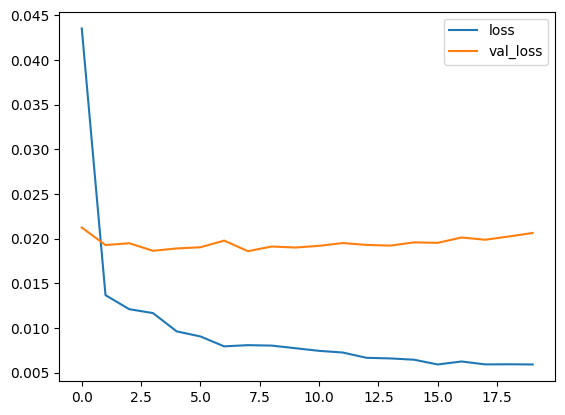

In [ ]:
losses = pd.DataFrame(gru_model.history.history)
losses.plot()

In [ ]:
test_gru_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

for i in range(len(test)):
  #get prediction 1 time stamp ahead
  current_pred = gru_model.predict(current_batch, verbose=0)[0] # Changed 'model' to 'gru_model' and added verbose=0 to suppress output
  #store prediction
  test_gru_predictions.append(current_pred)
  #update batch to now include prediction and drop first value
  current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

<Axes: title={'center': 'Actual vs GRU-Predicted WheelDiameter'}, xlabel='Date'>

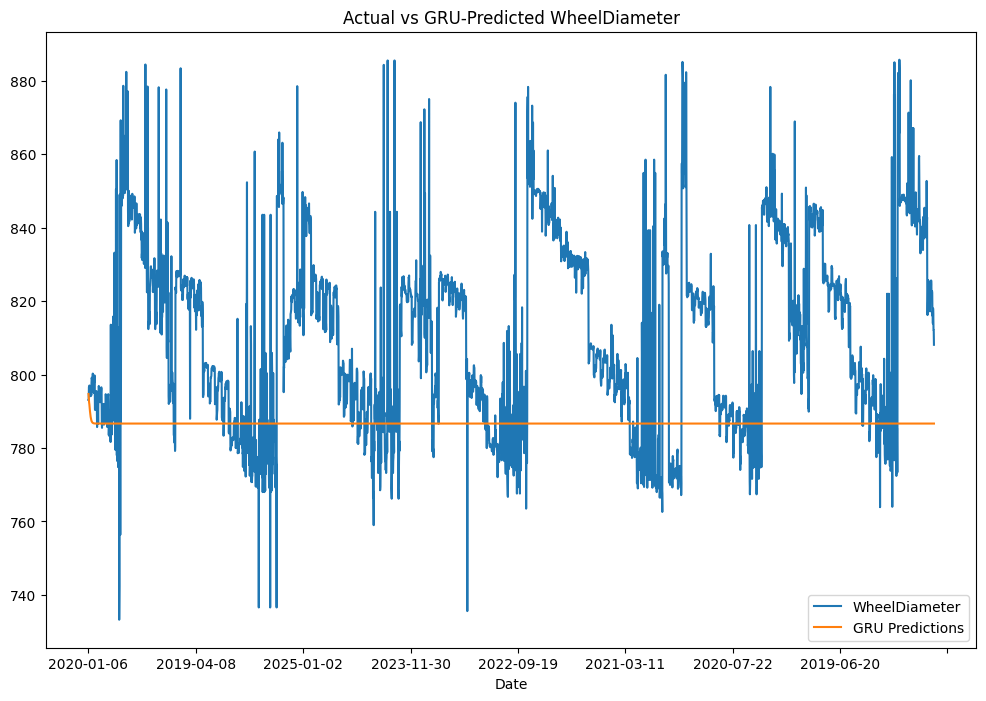

In [ ]:
true_prediction = scaler.inverse_transform(test_gru_predictions)
test['GRU Predictions'] = true_prediction
test[['WheelDiameter', 'GRU Predictions']].plot(figsize=(12,8), title='Actual vs GRU-Predicted WheelDiameter')

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from numpy import sqrt

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Inverse transform predictions if needed
true_prediction = scaler.inverse_transform(test_gru_predictions)
test['GRU Predictions'] = true_prediction.flatten()

# Inverse transform actual values if WheelDiameter is still scaled
# Uncomment the line below if your 'WheelDiameter' column is still scaled
# test['WheelDiameter'] = scaler.inverse_transform(test[['WheelDiameter']])

# Ground truth and prediction arrays
y_true = test['WheelDiameter'].values
y_pred = test['GRU Predictions'].values

# Metrics calculation
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mse = mean_squared_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Print results
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")


MAE:  37.8152
RMSE: 45.0708
MSE:  2031.3772
MAPE: 4.58%
R²:   -2.2787


<ipython-input-50-3eb4dc2ff023>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['GRU Predictions'] = true_prediction.flatten()


In [ ]:
gru_model = Sequential()
gru_model.add(GRU(50, activation='relu', input_shape=(length, n_features)))
gru_model.add(Dropout(0.2))

gru_model.add(Dense(1))

optimizer = Adam(learning_rate=0.0005) #default is 0.001;try lowering it to 0.0005
gru_model.compile(optimizer=optimizer, loss='mse')

gru_model.fit(generator, epochs=4)

Epoch 1/4


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


973/973 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0539
Epoch 2/4
973/973 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0094
Epoch 3/4
973/973 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0103
Epoch 4/4
973/973 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0085


In [ ]:
# Scale the entire dataset using the same scaler fitted on the training data
scaled_full_data = scaler.transform(df[numerical_cols])

forecast_gru = []
#Replace periods with whatever forecast length you want
periods = 4
first_eval_batch = scaled_full_data[-length:]
current_batch = first_eval_batch.reshape((1, length,n_features))

for i in range(periods):
  #get prediction 1 time stamp ahead
  current_pred_gru = gru_model.predict(current_batch, verbose=0)[0] # Added verbose=0 to suppress output

  forecast_gru.append(current_pred_gru)
  #update batch to now include prediction and drop first value
  current_batch = np.append(current_batch[:,1:,:],[[current_pred_gru]],axis=1) # Changed current_pred to current_pred_gru

In [ ]:
last_date = df.index[-1]
# Assuming daily frequency
forecast_index = pd.date_range(start=last_date, periods=periods+1, freq='D')[1:]

forecast_df = pd.DataFrame(forecast_gru,index=forecast_index,columns=['Forecast GRU'])

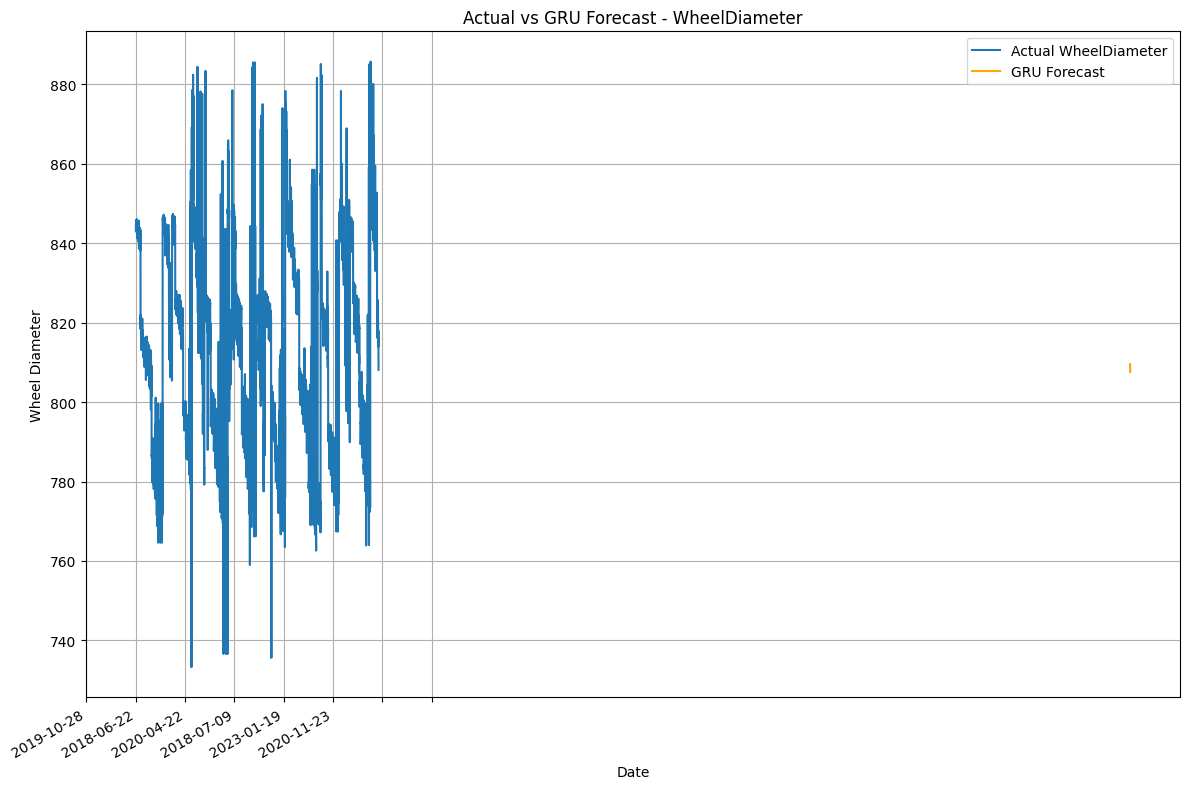

In [ ]:
import matplotlib.pyplot as plt

# Plotting actual and GRU forecasted WheelDiameter
ax = df['WheelDiameter'].plot(label='Actual WheelDiameter', figsize=(12, 8))
# Changed 'GRU Forecast' to 'Forecast GRU' to match the DataFrame column name
forecast_df['Forecast GRU'].plot(ax=ax, label='GRU Forecast', color='orange')

# Titles and labels
plt.title('Actual vs GRU Forecast - WheelDiameter')
plt.xlabel('Date')
plt.ylabel('Wheel Diameter')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()